# Análise Scada Café - BPS

### Calendário:

In [250]:
# Calcular fim do mês:
import datetime

hoje = datetime.date.today()
ano = hoje.year
mes = hoje.month
# Calcular último dia do mês corrente:
if mes == 12:
    ultimo_dia = datetime.date(ano + 1, 1, 1) - datetime.timedelta(days=1)
else:
    ultimo_dia = datetime.date(ano, mes + 1, 1) - datetime.timedelta(days=1)
# Calcular dias restantes:
dias_restantes = (ultimo_dia - hoje).days

print(f"Faltam {dias_restantes} dias para terminar o mês.")


Faltam 15 dias para terminar o mês.


### Importação de base

In [251]:
import pandas as pd

faturamento_df = pd.read_excel("base_bps.xlsx")
produtos_df = pd.read_excel('base_bps_produtos.xlsx')
perdas_df = pd.read_excel('base_perdas_bps.xlsx')

#base.info()
#produtos_df.info()
#perdas_df.info()

### Tratamento de dados

In [252]:
faturamento_df = faturamento_df.rename(columns={'Cupom Total': 'Cupons por Dia'}) # Renomear uma coluna
faturamento_df["% Meta"] = faturamento_df["Faturamento"] / faturamento_df["Meta"] * 100 # Acrescentando uma coluna com percentual da meta

faturamento_df["Mês"] = faturamento_df["Mês"].dt.month_name(locale="pt_BR") # Substituir formato da coluna Mês atual por descrição do mês

#display(faturamento_df) # Exibição simples do Dataframe

In [253]:
produtos_df["Mês"] = produtos_df["Mês"].dt.month_name(locale="pt_BR") # Substituir formato da coluna Mês atual por descrição do mês
#display(produtos_df) # Exibição simples do Dataframe

In [254]:
# Substituir formato da coluna Mês atual por descrição do mês
perdas_df["Mês"] = perdas_df["Mês"].dt.month_name(locale="pt_BR")
# Renomear colunas
perdas_df = perdas_df.rename(columns={'Item (Descrição do item da perda)': 'Item'})
perdas_df = perdas_df.rename(columns={'Quantidade (Qtd, peso, etc)': 'Quantidade'})
perdas_df = perdas_df.rename(columns={'Observação (Detalhamento. O que aconteceu?)': 'Observação'})

#display(perdas_df)

# Analise Resultados

## Resultados Vendas:

### Por Mês:

In [255]:
ordem_meses = [
    "Janeiro", "Fevereiro", "Março", "Abril", "Maio", "Junho",
    "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"
]

dados_mensal = faturamento_df.groupby("Mês")[["Faturamento", "Meta"]].sum().reset_index() # Gerar o somatório de faturamento por mês
#groupby("Mes") → agrupa as linhas por cada mês.
#["Faturamento"].sum() → soma os valores da coluna Faturamento dentro de cada grupo.
#.reset_index() → reorganiza o resultado em formato de tabela normal.

# Ordenar os meses de forma correta (crescente):
dados_mensal["Mês"] = pd.Categorical(
    dados_mensal["Mês"],
    categories=ordem_meses,
    ordered=True
)
dados_mensal = dados_mensal.sort_values("Mês")

display(dados_mensal)

,Mês,Faturamento,Meta
3,Janeiro,172628.28,182320.80
2,Fevereiro,157965.03,170279.32
7,Março,165999.96,177120.54
0,Abril,155280.58,182035.84
6,Maio,177103.76,189435.52
5,Junho,157151.19,183566.00
4,Julho,180446.39,188952.32
1,Agosto,170104.86,189584.99
10,Setembro,152614.73,183632.79
9,Outubro,159417.65,189755.79


### Por Dia:

In [256]:
dados_diarios = faturamento_df.groupby("Dia")["Faturamento"].sum().reset_index() # Gerar o somatório de faturamento por mês
#groupby("Mes") → agrupa as linhas por cada mês.
#["Faturamento"].sum() → soma os valores da coluna Faturamento dentro de cada grupo.
#.reset_index() → reorganiza o resultado em formato de tabela normal.

# Ordenar os meses de forma correta (crescente):
dados_diarios["Dia"] = pd.Categorical(
    dados_diarios["Dia"],
    #categories=ordem_meses,
    ordered=True
)
dados_diarios = dados_diarios.sort_values("Dia")

display(dados_diarios)

,Dia,Faturamento
0,2025-01-01,0.00
1,2025-01-02,6096.75
2,2025-01-03,5850.00
3,2025-01-04,7527.45
4,2025-01-05,4886.00
...,...,...
329,2025-11-26,0.00
330,2025-11-27,0.00
331,2025-11-28,0.00
332,2025-11-29,0.00


### Por produtos (mais vendidos no Ano e no Mês):

In [257]:
produtos_por_mes = produtos_df.loc[produtos_df['Mês'] == "Outubro", :] # Filtrar os dados do mês desejado
produtos_por_mes = produtos_por_mes.sort_values("Valor Total", ascending=False)

total_fat_ano = faturamento_df["Faturamento"].sum()

produtos_ano = produtos_df.groupby("Produto")["Valor Total"].sum().reset_index() # Somar o valor total por produto no ano
produtos_ano = produtos_ano.sort_values("Valor Total", ascending=False)
produtos_ano["% do Fat Total"] = produtos_ano["Valor Total"] / total_fat_ano #inserir coluna com percentual
produtos_ano["Média Fat Mensal"] = produtos_ano["Valor Total"] / mes #inserir coluna com média mensal

def formatar(valor): # Função para formatar valores em reais
    valor_formatado = f"R$ {valor:,.2f}"
    return valor_formatado

def formatar_perc(percentual): # Função para formatar valores percentuais
    percentual_formatado = f"{percentual:.2%}"
    return percentual_formatado

produtos_ano["Valor Total"] = produtos_ano["Valor Total"].apply(formatar)
produtos_ano["Média Fat Mensal"] = produtos_ano["Média Fat Mensal"].apply(formatar)
produtos_ano["% do Fat Total"] = produtos_ano["% do Fat Total"].apply(formatar_perc)

print(f"Faturamento Total Ano: R$ {total_fat_ano:,.2f}")
print("Produtos mais vendidos do Ano:")
display(produtos_ano.head(10)) # Exibir os 10 produtos mais vendidos do Ano
print("Produtos mais vendidos do Mês:")
display(produtos_por_mes)

Faturamento Total Ano: R$ 1,722,606.89
Produtos mais vendidos do Ano:


,Produto,Valor Total,% do Fat Total,Média Fat Mensal
144,ESPRESSO SIMPLES,"R$ 110,312.25",6.40%,"R$ 10,028.39"
178,PAO QUEIJO UNID,"R$ 55,908.00",3.25%,"R$ 5,082.55"
142,ESPRESSO LATTE DUPLO,"R$ 46,256.25",2.69%,"R$ 4,205.11"
77,CAPPUCCINO ITALIANO DUPLO,"R$ 45,780.50",2.66%,"R$ 4,161.86"
141,ESPRESSO DUPLO,"R$ 41,244.25",2.39%,"R$ 3,749.48"
34,AGUA GARRAFA S/ GAS,"R$ 39,234.00",2.28%,"R$ 3,566.73"
176,PAO QUEIJO PORCAO,"R$ 36,285.00",2.11%,"R$ 3,298.64"
129,CROISSANT MISTO,"R$ 32,719.50",1.90%,"R$ 2,974.50"
33,AGUA GARRAFA C/ GAS,"R$ 32,653.00",1.90%,"R$ 2,968.45"
44,BOLO BRIGADEIRO HOLANDES,"R$ 27,252.00",1.58%,"R$ 2,477.45"


Produtos mais vendidos do Mês:


,Mês,Cód.,Produto,Un.,Qtde.,Valor Unit.,Valor Total,% Total Venda,MTC
1889,Outubro,1,ESPRESSO SIMPLES,UN,1132,10.00,11320.00,7.11,312.10
1890,Outubro,1006,PAO QUEIJO UNID,UN,431,13.00,5603.00,3.52,118.83
1891,Outubro,315,CAPPUCCINO ITALIANO DUPLO,UN,267,18.50,4939.50,3.10,73.61
1892,Outubro,14,ESPRESSO LATTE DUPLO,UN,262,17.50,4585.00,2.88,72.24
1893,Outubro,2,ESPRESSO DUPLO,UN,273,15.50,4231.50,2.66,75.27
...,...,...,...,...,...,...,...,...,...
2060,Outubro,9147,AD MANTEIGA,UN,1,6.50,6.50,0.00,0.28
2061,Outubro,9991,AD PARMESÃO RALADO,UN,1,6.50,6.50,0.00,0.28
2062,Outubro,292,VOUCHER ESPRESSO SIMPLES,UN,13,0.01,0.13,0.00,3.58
2063,Outubro,802,VOUCHER CERVEJA HEINEKEN LG NECK,UN,1,0.01,0.01,0.00,0.28


### Criação de variáveis e funções

In [258]:
# Dados de Comissão:
dados_2025 = {
    "mes_atual": [
        {'Data': '01/11/25', 'Comissao': 595.75, 'EquipeDia': 12},
        {'Data': '02/11/25', 'Comissao': 504.45, 'EquipeDia': 12},
        {'Data': '03/11/25', 'Comissao': 477.95, 'EquipeDia': 13},
        {'Data': '04/11/25', 'Comissao': 405.85, 'EquipeDia': 13},
        {'Data': '05/11/25', 'Comissao': 438.70, 'EquipeDia': 13},
        {'Data': '06/11/25', 'Comissao': 477.70, 'EquipeDia': 13},
        {'Data': '07/11/25', 'Comissao': 479.85, 'EquipeDia': 13},
        {'Data': '08/11/25', 'Comissao': 416.65, 'EquipeDia': 12},
        {'Data': '09/11/25', 'Comissao': 545.40, 'EquipeDia': 10},
        {'Data': '10/11/25', 'Comissao': 418, 'EquipeDia': 13},
        {'Data': '11/11/25', 'Comissao': 515, 'EquipeDia': 13},
        {'Data': '12/11/25', 'Comissao': 393.15, 'EquipeDia': 12},
        {'Data': '13/11/25', 'Comissao': 436.25, 'EquipeDia': 12},
        {'Data': '14/11/25', 'Comissao': 436.25, 'EquipeDia': 13},

    ]
}

comissao_individual_equipe = round(sum((dia['Comissao'] / dia['EquipeDia']) * 0.80 for dia in dados_2025["mes_atual"]), 2)
media_comissao_dia = round(sum((dia['Comissao'] / dia['EquipeDia']) * 0.80 for dia in dados_2025["mes_atual"]) / len(dados_2025["mes_atual"]),4)
projecao_comiss_mes = comissao_individual_equipe + (media_comissao_dia * (dias_restantes + 1))


In [259]:
# FILTRAR MES CORRENTE em Faturamento:

df_mes_corrente = faturamento_df[
    (faturamento_df['Dia'].dt.year == 2025) &
    (faturamento_df['Dia'].dt.month == 11)
]


In [260]:

import calendar
import locale
# Configura o locale para Português do Brasil (Pode ser necessário dependendo do ambiente)
locale.setlocale(locale.LC_TIME, 'pt_BR.UTF-8') 
# Se a linha acima falhar, tente: locale.setlocale(locale.LC_TIME, 'portuguese')
# Método 2: Usando a biblioteca 'calendar' para ter controle do idioma
mes_numero = df_mes_corrente['Dia'].dt.month.iloc[0]
nome_do_mes_pt_br = calendar.month_name[mes_numero]
# Apenas para garantir que comece com letra maiúscula (o calendar.month_name retorna 'outubro')
nome_do_mes_corrente = nome_do_mes_pt_br.capitalize()

# VARIÁVEIS DE APOIO:
meta_mes_corrente = df_mes_corrente["Meta"].sum()
soma_faturamento = df_mes_corrente['Faturamento'].sum()
faturamento_medio_dia = df_mes_corrente['Faturamento'].mean()
total_cupons_mes = df_mes_corrente['Cupons por Dia'].sum()
ticket_medio_dia = soma_faturamento / total_cupons_mes
media_cupons_dia = df_mes_corrente['Cupons por Dia'].mean()
projecao_faturamento = soma_faturamento + (faturamento_medio_dia * dias_restantes)
ticket_meta_dia = (meta_mes_corrente - soma_faturamento) / total_cupons_mes * media_cupons_dia / dias_restantes
fat_meta_dia = (meta_mes_corrente - soma_faturamento) / dias_restantes
ticket_meta_dia = (meta_mes_corrente - soma_faturamento) / media_cupons_dia / dias_restantes
fat_total_eq_1 = df_mes_corrente[df_mes_corrente['Equipe'] == 1]['Faturamento'].sum()
fat_total_eq_2 = df_mes_corrente[df_mes_corrente['Equipe'] == 2]['Faturamento'].sum()
ticket_eq_1 = df_mes_corrente[df_mes_corrente['Equipe'] == 1]['Ticket Médio'].mean()
ticket_eq_2 = df_mes_corrente[df_mes_corrente['Equipe'] == 2]['Ticket Médio'].mean()
total_dias_eq_1 = df_mes_corrente[df_mes_corrente['Equipe'] == 1]['Dia'].nunique()
total_dias_eq_2 = df_mes_corrente[df_mes_corrente['Equipe'] == 2]['Dia'].nunique()


# Resumo Resultados:

In [261]:
# EXIBIÇÕES:
#comissao_outubro = calcular_comissao(dados_2025, mes_corrente)
#ticket_outubro = calcular_ticket(dados_2025, mes_corrente)
print(f'- DADOS FATURAMENTO - {nome_do_mes_corrente}:')
print(f'Meta Mês: R$ {meta_mes_corrente:,.2f}')
print(f'Faturamento: R$ {soma_faturamento:,.2f}')
print(f'% Meta: {soma_faturamento / meta_mes_corrente:.0%}')
print(f'Faturamento Médio Dia: R$ {faturamento_medio_dia:,.2f}')
print(f'Ticket Médio Dia: R$ {ticket_medio_dia:,.2f}')
print(f'Média Cupons Dia: {media_cupons_dia:.0f}')
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('- PROJEÇÕES E RECUPERAÇÃO META:')
print(f'Ainda faltam R$ {meta_mes_corrente - soma_faturamento:,.2f} para atingirmos a  meta do mês.')
print(f'Estamos projetando R$ {projecao_faturamento:,.2f} de faturamento no mês.')
print(f'Precisamos de R$ {ticket_meta_dia:,.0f} por mesa ou R$ {fat_meta_dia:,.0f} por dia para alcançarmos a meta do mês.')
print(f'Isso representa R$ {ticket_meta_dia - ticket_medio_dia:,.0f} a mais por mesa mediante aos R$ {ticket_medio_dia:,.0f} realizado atualmente.')
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('- RESULTADO POR EQUIPE:')
print(f'Faturamento Equipe 01: R$ {fat_total_eq_1:,.0f}')
print(f'Faturamento Equipe 02: R$ {fat_total_eq_2:,.0f}')
print(f'Ticket Médio Equipe 01: R$ {ticket_eq_1:,.0f}')
print(f'Ticket Médio Equipe 02: R$ {ticket_eq_2:,.0f}')
print(f"Dias trabalhados Equipe 1: {total_dias_eq_1}")
print(f"Dias trabalhados Equipe 2: {total_dias_eq_2}")
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('- DADOS COMISSÃO:')
print(f'Comissão individual acumulada: R$ {comissao_individual_equipe:,.2f}')
print(f'Média Comissão dia: R$ {media_comissao_dia:,.2f}')
print(f'Projeção Mês: R$ {projecao_comiss_mes:,.2f}')
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')


- DADOS FATURAMENTO - Novembro:
Meta Mês: R$ 184,034.29
Faturamento: R$ 73,894.46
% Meta: 40%
Faturamento Médio Dia: R$ 5,278.18
Ticket Médio Dia: R$ 42.81
Média Cupons Dia: 123
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
- PROJEÇÕES E RECUPERAÇÃO META:
Ainda faltam R$ 110,139.83 para atingirmos a  meta do mês.
Estamos projetando R$ 153,067.10 de faturamento no mês.
Precisamos de R$ 60 por mesa ou R$ 7,343 por dia para alcançarmos a meta do mês.
Isso representa R$ 17 a mais por mesa mediante aos R$ 43 realizado atualmente.
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
- RESULTADO POR EQUIPE:
Faturamento Equipe 01: R$ 38,572
Faturamento Equipe 02: R$ 35,323
Ticket Médio Equipe 01: R$ 43
Ticket Médio Equipe 02: R$ 43
Dias trabalhados Equipe 1: 15
Dias trabalhados Equipe 2: 15
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
- DADOS COMISSÃO:
Comissão in

## Perdas:

### Por Mês

In [262]:
# Agrupar perdas por mês
perdas_por_mes = perdas_df.groupby("Mês")[["Quantidade"]].count().reset_index()

# Ordenar meses de forma correta (crescente):
perdas_por_mes["Mês"] = pd.Categorical(perdas_por_mes["Mês"], categories=ordem_meses, ordered=True)
perdas_por_mes = perdas_por_mes.sort_values("Mês").reset_index(drop=True)

display(perdas_por_mes)

,Mês,Quantidade
0,Janeiro,72
1,Fevereiro,69
2,Março,61
3,Abril,48
4,Maio,51
5,Junho,38
6,Julho,50
7,Agosto,41
8,Setembro,42
9,Outubro,37


### Por Motivo:

In [263]:
# Filtrar perdas do mês corrente
perdas_mes_corrente = perdas_df[perdas_df['Mês'] == nome_do_mes_corrente]
# Contagem por Motivo
perdas_motivo = perdas_mes_corrente.groupby("Motivo")[["Item"]].count().reset_index()
perdas_motivo = perdas_motivo.sort_values("Item", ascending=False).reset_index(drop=True) # Ordenar por quantidade de perdas


display(perdas_mes_corrente)
display(perdas_motivo)

,Carimbo de data/hora,Data da perda,Item,Categoria,Quantidade,Motivo,Responsável,Observação,Mês
510,2025-11-04 18:17:02.976,2025-11-04,Suco acerola com laranja,Produto final,1,Erro de processo,Alex,Deixou cair,Novembro
511,2025-11-06 21:51:56.448,2025-11-06,cappucino scada,Produto final,1,Cliente,Beatriz,cliente nao gostou do sabor,Novembro
512,2025-11-07 20:41:07.296,2025-11-07,xote,Utensílio,1,Quebra,Patrícia,deixou cae,Novembro
513,2025-11-07 20:43:20.352,2025-11-07,cha gelada fraboesa,Produto final,1,Erro de processo,Ana Júlia,fez errado,Novembro
514,2025-11-09 12:49:03.648,2025-11-09,latte duplo,Produto final,1,Lançamento errado,Francisca,era expresso duplo e lançou latte duplo,Novembro
515,2025-11-09 20:10:50.304,2025-11-09,shake oreeo,Produto final,1,Erro de processo,Edna,fez errado,Novembro
516,2025-11-09 20:11:44.736,2025-11-09,frango,Insumo,1,Erro de processo,Edna,deixou caier,Novembro
517,2025-11-09 20:12:51.264,2025-11-09,tomate,Hortifruti,989g,Venceu (Validade),Francisca,estava rui,Novembro
518,2025-11-10 21:19:33.312,2025-11-10,Xícara grande,Utensílio,1,Quebra,Alex,Trincada na alça,Novembro
519,2025-11-11 21:05:49.056,2025-11-11,torta cheesecake,Produto final,1,Venceu (Validade),Francisca,estava muito dura na vitreni,Novembro


,Motivo,Item
0,Erro de processo,4
1,Quebra,4
2,Venceu (Validade),4
3,Cliente,2
4,Lançamento errado,1


# Gráficos - Análise de Resultados

In [264]:
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

# Definir ciclo de cores personalizado usando a paleta 'tab10'
cores = plt.get_cmap('tab10').colors
ciclo_cores = cycler('color', cores)
plt.rc('axes', prop_cycle=ciclo_cores)

# === Ordem dos meses ===
ordem_meses = ["Janeiro", "Fevereiro", "Março", "Abril", "Maio", "Junho",
               "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"]

# Ordem meses em inglês:
ordem_meses_ingles = ["January", "February", "March", "April", "May", "June",
                      "July", "August", "September", "October", "November", "December"]


/var/folders/f3/8ygjt7g576ngdk4sjg90gxwm0000gn/T/ipykernel_1381/628409478.py:29: UserWarning: Legend does not support handles for Annotation instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


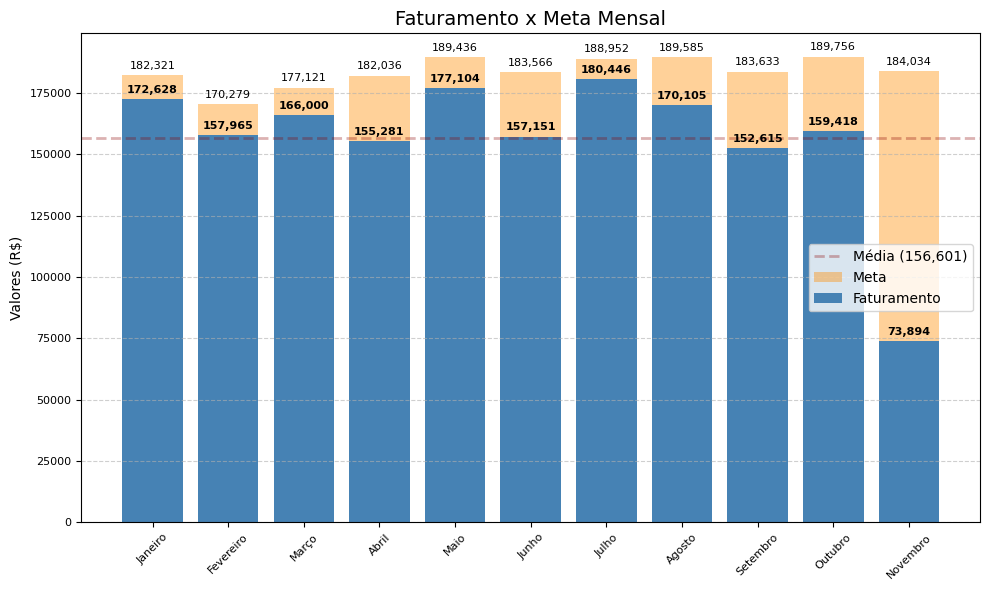

In [265]:
# FATURAMENTO X META MENSAL:
dados_mensal = faturamento_df.groupby("Mês")[["Faturamento", "Meta"]].sum().reset_index()
media_faturamento = dados_mensal["Faturamento"].mean()

# === Ordenar meses ===
dados_mensal["Mês"] = pd.Categorical(dados_mensal["Mês"],
                                     categories=ordem_meses,
                                     ordered=True)
dados_mensal = dados_mensal.sort_values("Mês")

# === Criar o gráfico de barras ===
plt.figure(figsize=(10, 6))

barras_meta = plt.bar(dados_mensal["Mês"], dados_mensal["Meta"], label="Meta", color="darkorange", alpha=0.4)
barras_faturamento = plt.bar(dados_mensal["Mês"], dados_mensal["Faturamento"],label="Faturamento", color="steelblue")
plt.bar_label(barras_meta, fmt="{:,.0f}", padding=3, fontsize=8, label='Meta')
plt.bar_label(barras_faturamento, fmt="{:,.0f}", padding=3, fontsize=8, label='Faturamento', fontweight='bold')

# === Linha média ===
plt.axhline(y=media_faturamento, color="darkred", linestyle="--", alpha=0.3, linewidth=2,
            label=f"Média ({media_faturamento:,.0f})")

# === Personalização ===
plt.title("Faturamento x Meta Mensal", fontsize=14)
#plt.xlabel("Mês")
plt.ylabel("Valores (R$)")
plt.xticks(dados_mensal["Mês"], rotation=45, fontsize=8)
plt.yticks(fontsize=8)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

#plt.savefig("faturamento_x_meta_mensal.png", dpi=300)

plt.tight_layout()
plt.show()




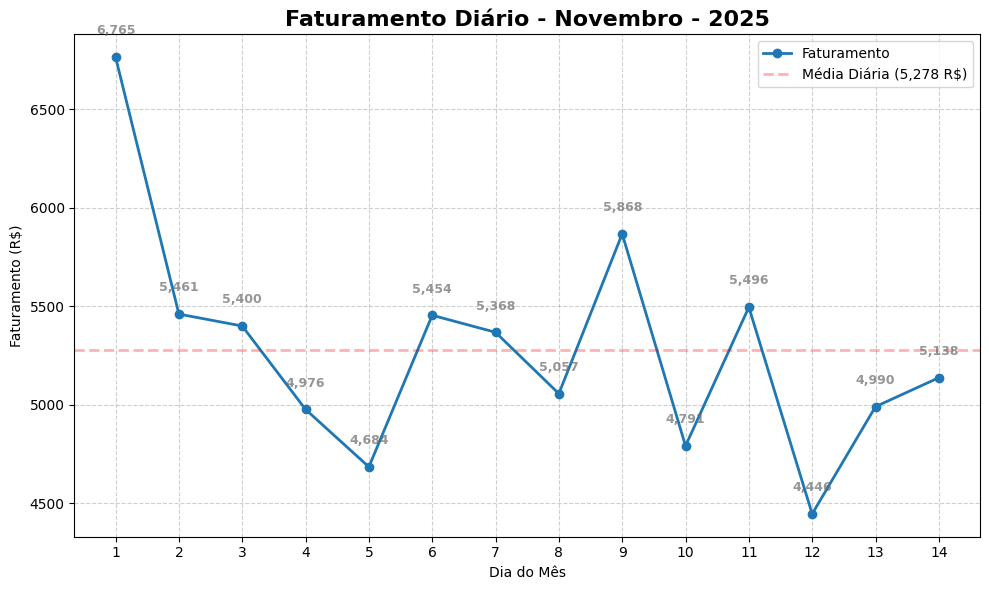

In [266]:
# FATURAMENTO POR DIA:
# Agrupar por dia e somar o Faturamento
# Nota: Como já filtramos por mês, o 'Dia' aqui será o dia do mês (1, 2, 3...)
dados_diarios_mes = df_mes_corrente.groupby(df_mes_corrente['Dia'].dt.day)['Faturamento'].sum().reset_index()

# NOVIDADE CRUCIAL: FILTRAR APENAS DIAS COM FATURAMENTO MAIOR QUE ZERO
dados_diarios_mes = dados_diarios_mes[
    dados_diarios_mes['Faturamento'] > 0
].reset_index(drop=True) # O reset_index é opcional, mas boa prática após um filtro

# --- NOVIDADE: 1.4 Calcular a Média ---
media_diaria = dados_diarios_mes['Faturamento'].mean()

# --- 2. Criação do Gráfico de Linha ---
plt.figure(figsize=(10, 6))

# plt.plot() é o comando para gráficos de linha
plt.plot(
    dados_diarios_mes['Dia'],
    dados_diarios_mes['Faturamento'],
    marker='o',          # Adiciona um marcador para cada dia
    linestyle='-',       # Linha contínua
    linewidth=2,
    label="Faturamento"
)

# --- NOVIDADE: Linha de Média ---
plt.axhline(
    y=media_diaria,
    color='red',
    linestyle='--', # Linha tracejada
    alpha=0.3,
    linewidth=2,
    label=f"Média Diária ({media_diaria:,.0f} R$)" # Adicionar label da média na legenda com o valor formatado
)

# --- NOVIDADE: Valores sobre os Pontos (Rótulos de Dados) ---
for dia, faturamento in zip(dados_diarios_mes['Dia'], dados_diarios_mes['Faturamento']):
    plt.text(
        dia, 
        faturamento + 100,  # Adiciona um pequeno offset (+500) para ficar acima do ponto
        f"{faturamento:,.0f}", # Formata o valor sem casas decimais e com separador de milhar
        ha='center',        # Alinhamento horizontal: centralizado no ponto
        va='bottom',        # Alinhamento vertical: acima do ponto
        fontsize=9,
        alpha=0.7,
        color='dimgrey',
        weight='bold'
    )

# --- 3. Personalização e Visualização ---
plt.title(f'Faturamento Diário - {nome_do_mes_corrente} - 2025', fontsize=16, weight='bold')
plt.xlabel('Dia do Mês', fontsize=10)
plt.ylabel('Faturamento (R$)', fontsize=10)

# Garantir que todos os dias de Outubro (1 a 31) apareçam no eixo X
dias = range(1, len(dados_diarios_mes) + 1)
plt.xticks(dias)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout() # Ajusta automaticamente o layout
plt.show()

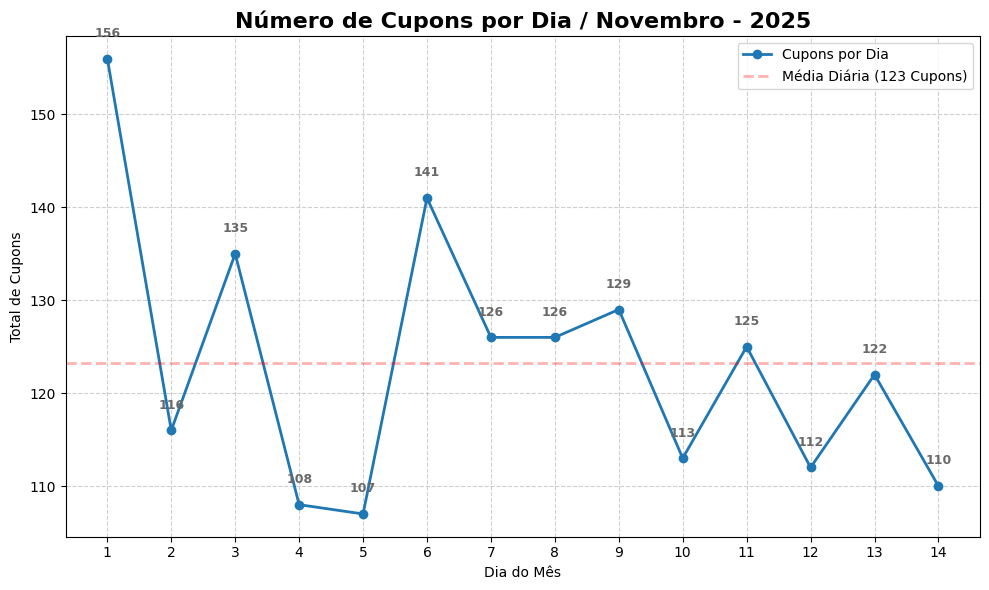

In [267]:
# CUPONS POR DIA:
# 2. Agrupamento
dados_cupons_mes_corrente = df_mes_corrente.groupby(df_mes_corrente['Dia'].dt.day)[
    'Cupons por Dia'
].sum().reset_index()
dados_cupons_mes_corrente.columns = ['Dia do Mês', 'Cupons por Dia']

# NOVIDADE CRUCIAL: FILTRAR APENAS DIAS COM FATURAMENTO MAIOR QUE ZERO
dados_cupons_mes_corrente = dados_cupons_mes_corrente[
    dados_cupons_mes_corrente['Cupons por Dia'] > 0
].reset_index(drop=True) # O reset_index é opcional, mas boa prática após um filtro

# 🚨 NOVIDADE: Calcular a Média de Cupons
media_cupons_mes_corrente = dados_cupons_mes_corrente['Cupons por Dia'].mean()

# 3. Criação do Gráfico de Linha
plt.figure(figsize=(10, 6))

# Gráfico de Linha
plt.plot(
    dados_cupons_mes_corrente['Dia do Mês'],
    dados_cupons_mes_corrente['Cupons por Dia'],
    marker='o',
    linestyle='-',
    linewidth=2,
    label='Cupons por Dia'
)

# 🚨 NOVIDADE: Linha de Média
plt.axhline(
    y=media_cupons_mes_corrente,
    color='red',
    linestyle='--', # Linha tracejada
    alpha=0.3,
    linewidth=2,
    label=f"Média Diária ({media_cupons_mes_corrente:,.0f} Cupons)" # Adicionar label da média na legenda com o valor formatado
)

# 🚨 NOVIDADE: Valores sobre os Pontos (Rótulos de Dados)
# Itera sobre os dados para posicionar o texto
for dia, cupons in zip(dados_cupons_mes_corrente['Dia do Mês'], dados_cupons_mes_corrente['Cupons por Dia']):
    plt.text(
        dia,
        cupons + 2, # Adiciona um pequeno offset (+2) para ficar acima do ponto
        f"{cupons:,.0f}", # Formata o valor sem casas decimais
        ha='center',
        va='bottom',
        fontsize=9,
        color='dimgrey',
        weight='bold'
    )

# 4. Personalização
plt.title(f'Número de Cupons por Dia / {nome_do_mes_corrente} - 2025', fontsize=16, weight='bold')
plt.xlabel('Dia do Mês', fontsize=10)
plt.ylabel('Total de Cupons', fontsize=10)

# Garante que todos os dias presentes apareçam no eixo X
#plt.xticks(dados_cupons_mes_corrente['Dia do Mês'])
dias = range(1, len(dados_cupons_mes_corrente) + 1)
plt.xticks(dias)

plt.legend() # Exibir legenda - Caso queira fixar a mesma em local específico, use plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

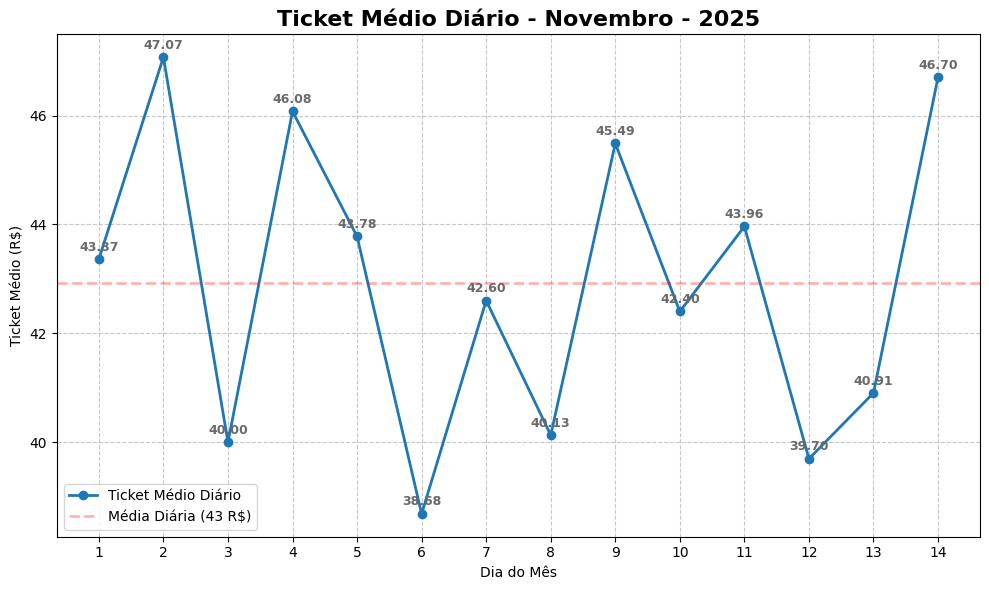

In [268]:
# TICKET MÉDIO POR DIA:
ticket_medio_mes_corrente = df_mes_corrente.groupby(df_mes_corrente['Dia'].dt.day)['Ticket Médio'].mean().reset_index()
# Gráfico de linhas:
plt.figure(figsize=(10, 6))
plt.plot(
    ticket_medio_mes_corrente['Dia'],
    ticket_medio_mes_corrente['Ticket Médio'],
    marker='o',
    linestyle='-',
    linewidth=2,
    label='Ticket Médio Diário'
)

# NOVIDADE CRUCIAL: FILTRAR APENAS DIAS COM FATURAMENTO MAIOR QUE ZERO
ticket_medio_mes_corrente = ticket_medio_mes_corrente[
    ticket_medio_mes_corrente['Ticket Médio'] > 0
].reset_index(drop=True) # O reset_index é opcional, mas boa prática após um filtro

# Linha de Média
media_ticket_mes_corrente = ticket_medio_mes_corrente['Ticket Médio'].mean()
plt.axhline(
    y=media_ticket_mes_corrente,
    color='red',
    linestyle='--', # Linha tracejada
    alpha=0.3,
    linewidth=2,
    label=f"Média Diária ({media_ticket_mes_corrente:,.0f} R$)" # Adicionar label da média na legenda com o valor formatado
)
# Valores sobre os Pontos (Rótulos de Dados)
for dia, ticket in zip(ticket_medio_mes_corrente['Dia'], ticket_medio_mes_corrente['Ticket Médio']):
    plt.text(
        dia,
        ticket + 0.1,  # Adiciona um pequeno offset (+5) para ficar acima do ponto
        f"{ticket:,.2f}", # Formata o valor sem casas decimais e com separador de milhar
        ha='center',
        va='bottom',
        fontsize=9,
        color='dimgrey',
        weight='bold'
    )
# Personalização   
plt.title(f'Ticket Médio Diário - {nome_do_mes_corrente} - 2025', fontsize=16, weight='bold')
plt.xlabel('Dia do Mês', fontsize=10)
plt.ylabel('Ticket Médio (R$)', fontsize=10)
# Garante que todos os dias presentes apareçam no eixo X
dias = range(1, len(ticket_medio_mes_corrente) + 1)
plt.xticks(dias)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


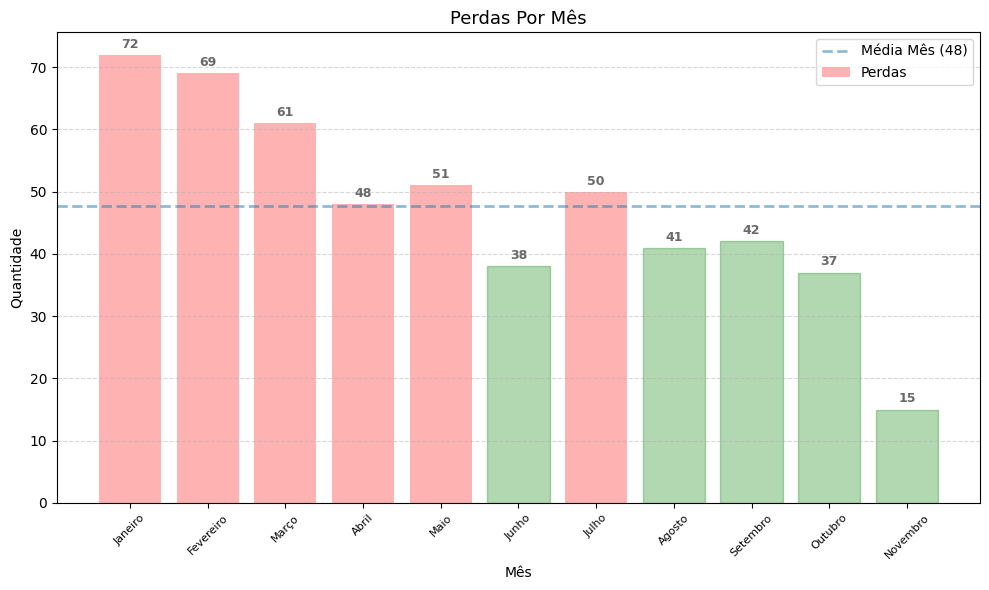

In [269]:
# PERDAS POR MÊS:
plt.figure(figsize=(10, 6))

barras = plt.bar(perdas_por_mes['Mês'], perdas_por_mes['Quantidade'], color='red', alpha=0.3, label='Perdas')
media_perdas_mes = perdas_por_mes['Quantidade'].mean()

# --- NOVIDADE: Linha de Média ---
plt.axhline(
    y=media_perdas_mes,
    #color='salmon',
    linestyle='--', # Linha tracejada
    alpha=0.5,
    linewidth=2,
    label=f"Média Mês ({media_perdas_mes:,.0f})" # Adicionar label da média na legenda com o valor formatado
)

# === Personalização ===
plt.title('Perdas Por Mês', fontsize=13)
plt.xlabel("Mês")
plt.ylabel("Quantidade")
plt.xticks(perdas_por_mes["Mês"], rotation=45, fontsize=8)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()

# === Valores sobre as barras ===
plt.bar_label(
    barras, # Variável que recebeu a instrução do gráfico
    label=perdas_por_mes["Quantidade"], # Informação a ser exibida em cima de cada barra
    padding=3, # Posição do texto em relação à barra
    fontsize=9, # Tamanho da fonte
    fontweight='bold', # Fonte em negrito
    color="dimgrey" # Cor do texto
    )

# Muda a cor da barra para valores abaixo da média:
for i, barra in enumerate(barras):
    if perdas_por_mes["Quantidade"].iloc[i] < media_perdas_mes:
        barra.set_color('green')

# Destacar área no gráfico (exemplo: período de redução de perdas)
#plt.axvspan(4.5, 9.5, color='lightgreen', alpha=0.3) 
#plt.text(5.5, 70, 'Período de Redução de Perdas', fontsize=10, color='darkgreen')

plt.tight_layout() # Ajusta o layout automaticamente
plt.show()


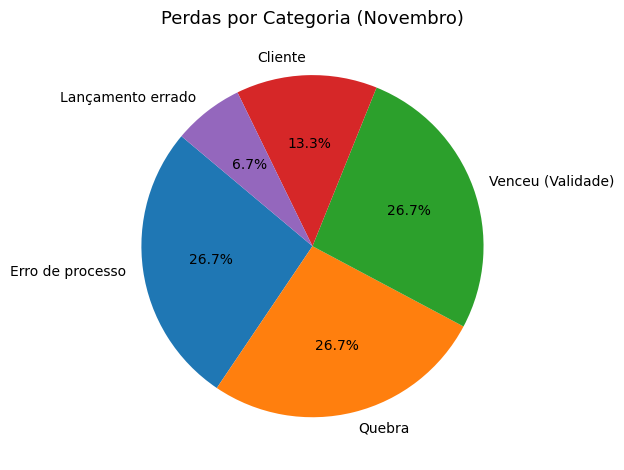

In [270]:
# PERDAS POR MOTIVO:
pizza = plt.pie(
    perdas_motivo['Item'],
    labels=perdas_motivo['Motivo'],
    autopct='%1.1f%%',
    startangle=140
)

# === Personalização ===
plt.title(f'Perdas por Categoria ({nome_do_mes_corrente})', fontsize=13)

plt.tight_layout() # Ajusta o layout automaticamente
plt.show()


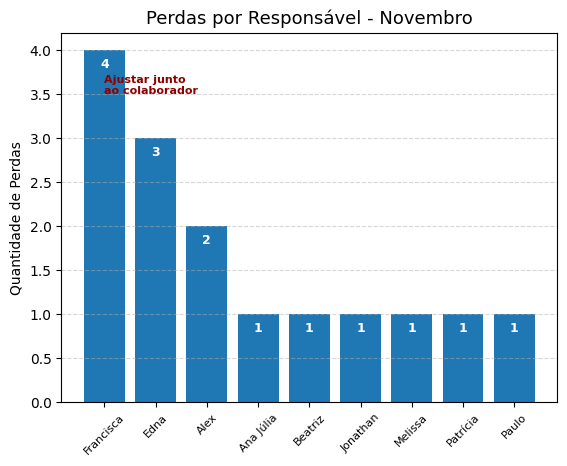

In [271]:
# PERDAS POR RESPONSÁVEL:
perdas_por_responsavel = perdas_mes_corrente.groupby("Responsável")['Item'].count().reset_index()
perdas_por_responsavel = perdas_por_responsavel.sort_values("Item", ascending=False).reset_index(drop=True)

plt.figuresize=(10, 6)
# Gráfico por responsável:
barras_responsavel = plt.bar(
    perdas_por_responsavel["Responsável"],
    perdas_por_responsavel["Item"],
)
# Valores sobre as barras:
plt.bar_label(
    barras_responsavel,
    label=perdas_por_responsavel["Item"],
    padding=-15,
    fontsize=9,
    fontweight='bold',
    color="white"
)

plt.text('Francisca', 3.5, 'Ajustar junto\nao colaborador', fontsize=8, color='darkred', weight='bold')

# Personalização:
plt.title(f"Perdas por Responsável - {nome_do_mes_corrente}", fontsize=13)
plt.ylabel("Quantidade de Perdas")
plt.xticks(rotation=45, fontsize=8)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


## Gráficos no formato AX:

/var/folders/f3/8ygjt7g576ngdk4sjg90gxwm0000gn/T/ipykernel_1381/3945554677.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(dados_mensal["Mês"], rotation=45, fontsize=8) # rotation=45, fontsize=8
/var/folders/f3/8ygjt7g576ngdk4sjg90gxwm0000gn/T/ipykernel_1381/3945554677.py:32: UserWarning: Legend does not support handles for Annotation instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


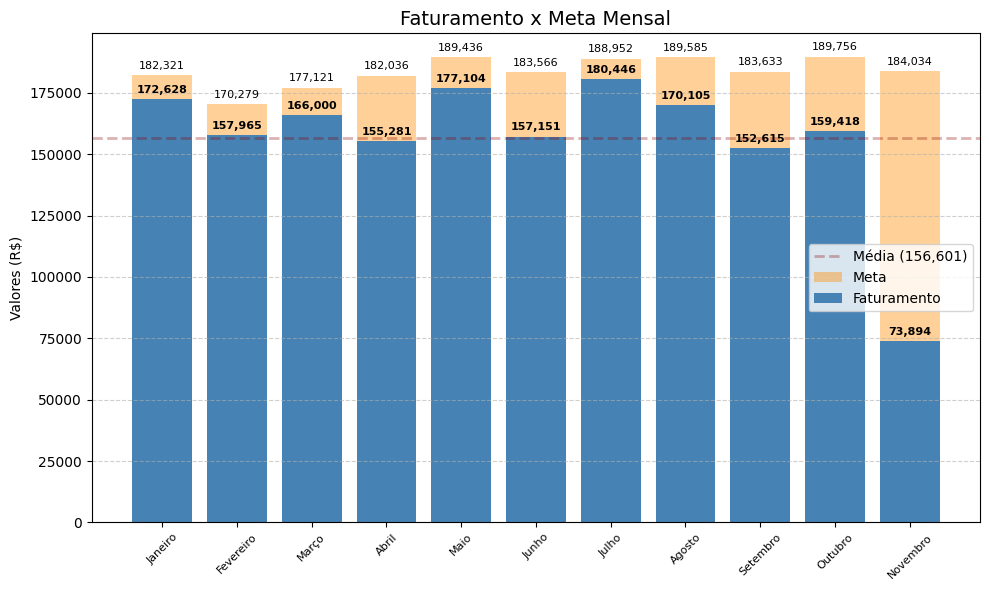

In [272]:
# FATURAMENTO X META MENSAL:
dados_mensal = faturamento_df.groupby("Mês")[["Faturamento", "Meta"]].sum().reset_index()
media_faturamento = dados_mensal["Faturamento"].mean()

# === Ordenar meses ===
dados_mensal["Mês"] = pd.Categorical(dados_mensal["Mês"],
                                     categories=ordem_meses,
                                     ordered=True)
dados_mensal = dados_mensal.sort_values("Mês")

# === Criar o gráfico de barras ===
fig, ax = plt.subplots(figsize=(10, 6))

#barras_meta = plt.bar(dados_mensal["Mês"], dados_mensal["Meta"], label="Meta", color="darkorange", alpha=0.4)
#barras_faturamento = plt.bar(dados_mensal["Mês"], dados_mensal["Faturamento"],label="Faturamento", color="steelblue")

barras_meta = ax.bar(dados_mensal["Mês"], dados_mensal["Meta"], label="Meta", color="darkorange", alpha=0.4)
barras_faturamento = ax.bar(dados_mensal["Mês"], dados_mensal["Faturamento"],label="Faturamento", color="steelblue")
ax.bar_label(barras_meta, fmt="{:,.0f}", padding=3, fontsize=8, label='Meta')
ax.bar_label(barras_faturamento, fmt="{:,.0f}", padding=3, fontsize=8, label='Faturamento', fontweight='bold')

# === Linha média ===
ax.axhline(y=media_faturamento, color="darkred", linestyle="--", alpha=0.3, linewidth=2,
            label=f"Média ({media_faturamento:,.0f})")

# === Personalização ===
ax.set_title("Faturamento x Meta Mensal", fontsize=14)
#ax.set_xlabel("Mês")
ax.set_ylabel("Valores (R$)")
ax.set_xticklabels(dados_mensal["Mês"], rotation=45, fontsize=8) # rotation=45, fontsize=8
#ax.set_yticklabels(fontsize=8)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.6)

#plt.savefig("faturamento_x_meta_mensal.png", dpi=300)

plt.tight_layout()
plt.show()




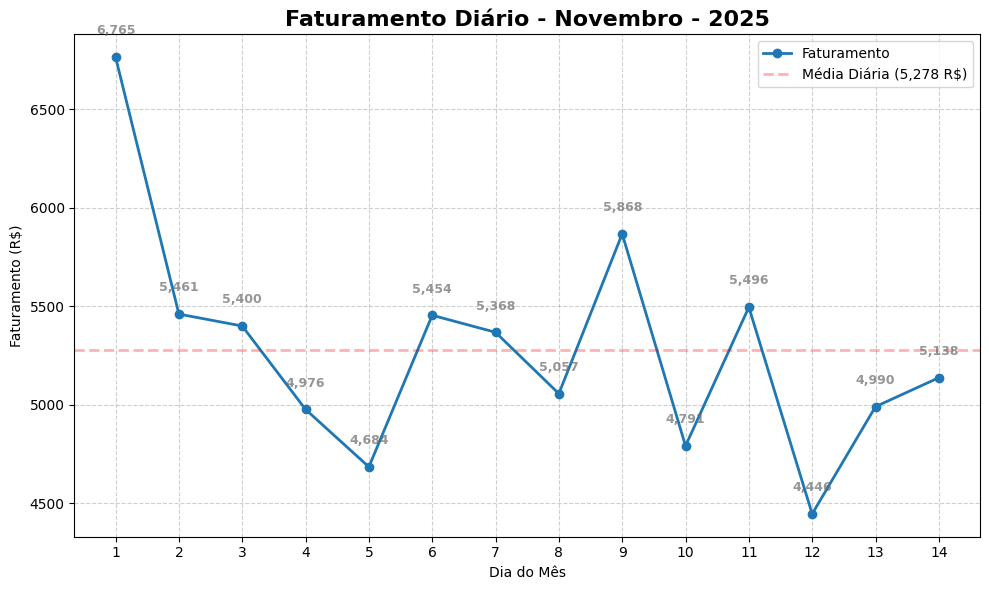

In [ ]:
# FATURAMENTO POR DIA:
# Agrupar por dia e somar o Faturamento
# Nota: Como já filtramos por mês, o 'Dia' aqui será o dia do mês (1, 2, 3...)
dados_diarios_mes = df_mes_corrente.groupby(df_mes_corrente['Dia'].dt.day)['Faturamento'].sum().reset_index()

# NOVIDADE CRUCIAL: FILTRAR APENAS DIAS COM FATURAMENTO MAIOR QUE ZERO
dados_diarios_mes = dados_diarios_mes[
    dados_diarios_mes['Faturamento'] > 0
].reset_index(drop=True) # O reset_index é opcional, mas boa prática após um filtro

# --- NOVIDADE: 1.4 Calcular a Média ---
media_diaria = dados_diarios_mes['Faturamento'].mean()

# --- 2. Criação do Gráfico de Linha ---
fig, ax0 = plt.subplots(figsize=(10, 6))

# plt.plot() é o comando para gráficos de linha
barras_meta = ax.bar(dados_mensal["Mês"], dados_mensal["Meta"], label="Meta", color="darkorange", alpha=0.4)

ax0.plot(
    dados_diarios_mes['Dia'],
    dados_diarios_mes['Faturamento'],
    marker='o',          # Adiciona um marcador para cada dia
    linestyle='-',       # Linha contínua
    linewidth=2,
    label="Faturamento"
)

# --- NOVIDADE: Linha de Média ---
ax0.axhline(
    y=media_diaria,
    color='red',
    linestyle='--', # Linha tracejada
    alpha=0.3,
    linewidth=2,
    label=f"Média Diária ({media_diaria:,.0f} R$)" # Adicionar label da média na legenda com o valor formatado
)

# --- NOVIDADE: Valores sobre os Pontos (Rótulos de Dados) ---
for dia, faturamento in zip(dados_diarios_mes['Dia'], dados_diarios_mes['Faturamento']):
    ax0.text(
        dia, 
        faturamento + 100,  # Adiciona um pequeno offset (+500) para ficar acima do ponto
        f"{faturamento:,.0f}", # Formata o valor sem casas decimais e com separador de milhar
        ha='center',        # Alinhamento horizontal: centralizado no ponto
        va='bottom',        # Alinhamento vertical: acima do ponto
        fontsize=9,
        alpha=0.7,
        color='dimgrey',
        weight='bold'
    )

# --- 3. Personalização e Visualização ---
ax0.set_title(f'Faturamento Diário - {nome_do_mes_corrente} - 2025', fontsize=16, weight='bold')
ax0.set_xlabel('Dia do Mês', fontsize=10)
ax0.set_ylabel('Faturamento (R$)', fontsize=10)

# Garantir que todos os dias de Outubro (1 a 31) apareçam no eixo X
dias = range(1, len(dados_diarios_mes) + 1)
ax0.set_xticks(dias)

ax0.legend()
ax0.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ajusta automaticamente o layout
plt.show()

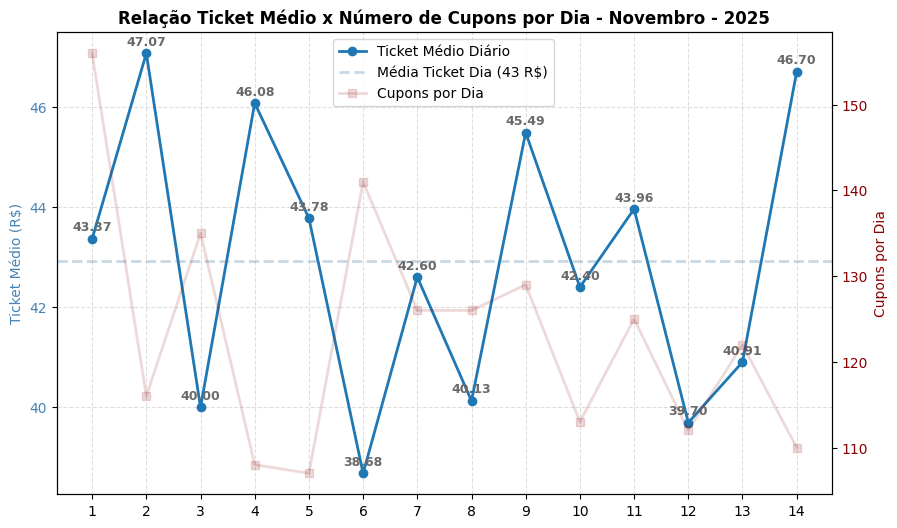

In [273]:
# RELAÇÃO TICKET MÉDIO X NÚMERO DE CUPONS:
# VARIÁVEIS TICKET: - - - - - - - - - - - - - - - - - - - - - - - - 
ticket_medio_mes_corrente = df_mes_corrente.groupby(df_mes_corrente['Dia'].dt.day)['Ticket Médio'].mean().reset_index()
# Filtrar faturamento maior que '0':
ticket_medio_mes_corrente = ticket_medio_mes_corrente[
    ticket_medio_mes_corrente['Ticket Médio'] > 0
].reset_index(drop=True) # O reset_index é opcional, mas boa prática após um filtro
# Linha de Média
media_ticket_mes_corrente = ticket_medio_mes_corrente['Ticket Médio'].mean()

# VARIÁVEIS CUPONS: - - - - - - - - - - - - - - - - - - - - - - - - 
dados_cupons_mes_corrente = df_mes_corrente.groupby(df_mes_corrente['Dia'].dt.day)['Cupons por Dia'].sum().reset_index()
#dados_cupons_mes_corrente.columns = ['Dia do Mês', 'Cupons por Dia']
# Filtrar cupos maior que '0':
dados_cupons_mes_corrente = dados_cupons_mes_corrente[dados_cupons_mes_corrente['Cupons por Dia'] > 0].reset_index(drop=True)
# O reset_index é opcional, mas boa prática após um filtro
# Calcular a Média de Cupons
media_cupons_mes_corrente = dados_cupons_mes_corrente['Cupons por Dia'].mean()

# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

# CONSTRUÇÃO DO GRÁFICO COM DOIS EIXOS Y:
fig, ax1 = plt.subplots(figsize=(10, 6))
plt.xticks(ticket_medio_mes_corrente['Dia'])
plt.grid(True, linestyle='--', alpha=0.4)

# Primeiro eixo Y - Ticket Médio:
ax1.plot(ticket_medio_mes_corrente['Dia'], ticket_medio_mes_corrente['Ticket Médio'],
         marker='o', linestyle='-', linewidth=2, label='Ticket Médio Diário')
ax1.set_ylabel('Ticket Médio (R$)', color='steelblue')
ax1.tick_params(axis='y', labelcolor="steelblue")
ax1.set_title(f'Relação Ticket Médio x Número de Cupons por Dia - {nome_do_mes_corrente} - 2025', fontsize=12, weight='bold')

# Linha de Média Ticket Médio:
media_ticket_mes_corrente = ticket_medio_mes_corrente['Ticket Médio'].mean()
plt.axhline(
    y=media_ticket_mes_corrente,
    color='steelblue',
    linestyle='--', # Linha tracejada
    alpha=0.3,
    linewidth=2,
    label=f"Média Ticket Dia ({media_ticket_mes_corrente:,.0f} R$)" # Adicionar label da média na legenda com o valor formatado
)
# Valores sobre os Pontos Ticket Médio (Rótulos de Dados):
for dia, ticket in zip(ticket_medio_mes_corrente['Dia'], ticket_medio_mes_corrente['Ticket Médio']):
    plt.text(
        dia,
        ticket + 0.1,  # Adiciona um pequeno offset (+5) para ficar acima do ponto
        f"{ticket:,.2f}", # Formata o valor sem casas decimais e com separador de milhar
        ha='center',
        va='bottom',
        fontsize=9,
        color='dimgrey',
        weight='bold'
    )

# - - - - - - - - - - - - - - - - - - - - - - - - - - -
ax2 = ax1.twinx()  # Criar um segundo eixo Y compartilhando o eixo X
# - - - - - - - - - - - - - - - - - - - - - - - - - - -

# Segundo eixo Y - Cupons por Dia:
ax2.plot(dados_cupons_mes_corrente['Dia'], dados_cupons_mes_corrente['Cupons por Dia'],
         marker='s', linestyle='-', color='darkred', linewidth=2, alpha=0.15, label='Cupons por Dia')
ax2.set_ylabel('Cupons por Dia', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')


# Adicionar legendas ancorando a posição fixa (x, y) / bbox_transform para posicionar em relação a área do gráfico
fig.legend(bbox_to_anchor=(0.65, 1), bbox_transform=ax1.transAxes)

plt.show()

/var/folders/f3/8ygjt7g576ngdk4sjg90gxwm0000gn/T/ipykernel_1381/2407603351.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(perdas_por_mes["Mês"], rotation=45, fontsize=8)


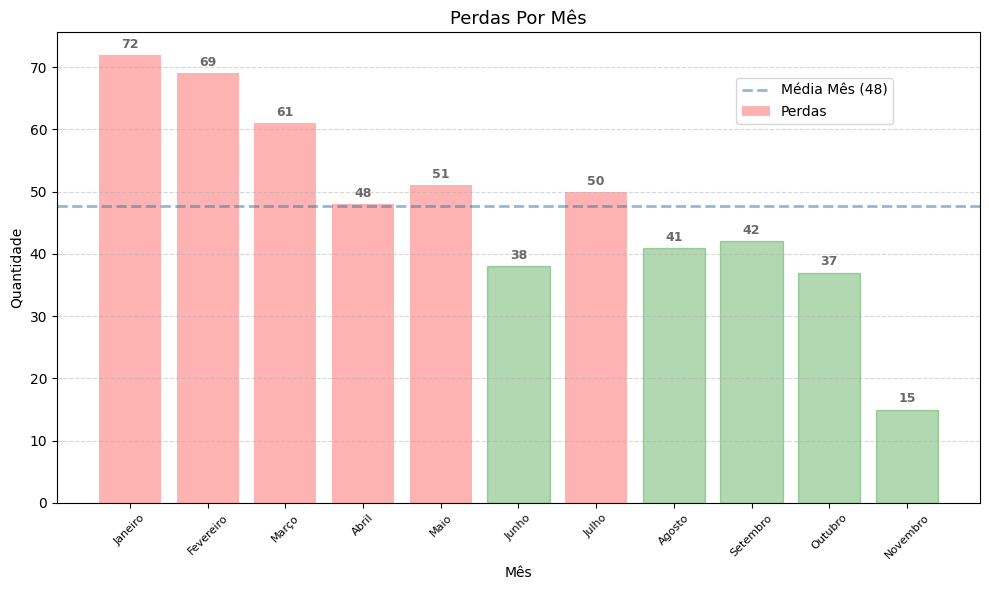

In [274]:
# PERDAS POR MÊS:
fig, ax3 = plt.subplots(figsize=(10, 6))

perdas_mes = ax3.bar(perdas_por_mes['Mês'], perdas_por_mes['Quantidade'], color='red', alpha=0.3, label='Perdas')
media_perdas_mes = perdas_por_mes['Quantidade'].mean()

# --- NOVIDADE: Linha de Média ---
plt.axhline(
    y=media_perdas_mes,
    #color='salmon',
    linestyle='--', # Linha tracejada
    alpha=0.5,
    linewidth=2,
    label=f"Média Mês ({media_perdas_mes:,.0f})" # Adicionar label da média na legenda com o valor formatado
)

# === Personalização ===
ax3.set_title('Perdas Por Mês', fontsize=13)
ax3.set_xlabel("Mês")
ax3.set_ylabel("Quantidade")
ax3.set_xticklabels(perdas_por_mes["Mês"], rotation=45, fontsize=8)
plt.grid(axis="y", linestyle="--", alpha=0.5)
fig.legend(bbox_to_anchor=(1, 0.98), bbox_transform=ax1.transAxes)

# === Valores sobre as barras ===
ax3.bar_label(
    perdas_mes, # Variável que recebeu a instrução do gráfico
    label=perdas_por_mes["Quantidade"], # Informação a ser exibida em cima de cada barra
    padding=3, # Posição do texto em relação à barra
    fontsize=9, # Tamanho da fonte
    fontweight='bold', # Fonte em negrito
    color="dimgrey" # Cor do texto
    )

# Muda a cor da barra para valores abaixo da média:
for i, barra in enumerate(perdas_mes):
    if perdas_por_mes["Quantidade"].iloc[i] < media_perdas_mes:
        barra.set_color('green')

# Destacar área no gráfico (exemplo: período de redução de perdas)
#plt.axvspan(4.5, 9.5, color='lightgreen', alpha=0.3) 
#plt.text(5.5, 70, 'Período de Redução de Perdas', fontsize=10, color='darkgreen')

plt.tight_layout() # Ajusta o layout automaticamente
plt.show()


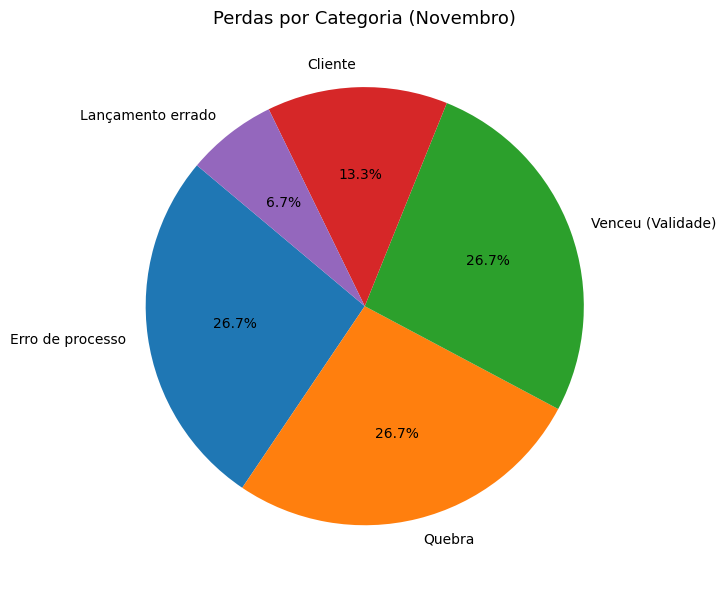

In [275]:
# PERDAS POR MOTIVO:
fig, ax4 = plt.subplots(figsize=(10, 6))

perdas_cat = ax4.pie(
    perdas_motivo['Item'],
    labels=perdas_motivo['Motivo'],
    autopct='%1.1f%%',
    startangle=140
)

# === Personalização ===
ax4.set_title(f'Perdas por Categoria ({nome_do_mes_corrente})', fontsize=13)

plt.tight_layout() # Ajusta o layout automaticamente
plt.show()

## Construção de DASH:

/var/folders/f3/8ygjt7g576ngdk4sjg90gxwm0000gn/T/ipykernel_1381/2451534455.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs["A"].set_xticklabels(dados_mensal["Mês"], rotation=45, fontsize=8) # rotation=45, fontsize=8
/var/folders/f3/8ygjt7g576ngdk4sjg90gxwm0000gn/T/ipykernel_1381/2451534455.py:36: UserWarning: Legend does not support handles for Annotation instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axs["A"].legend()


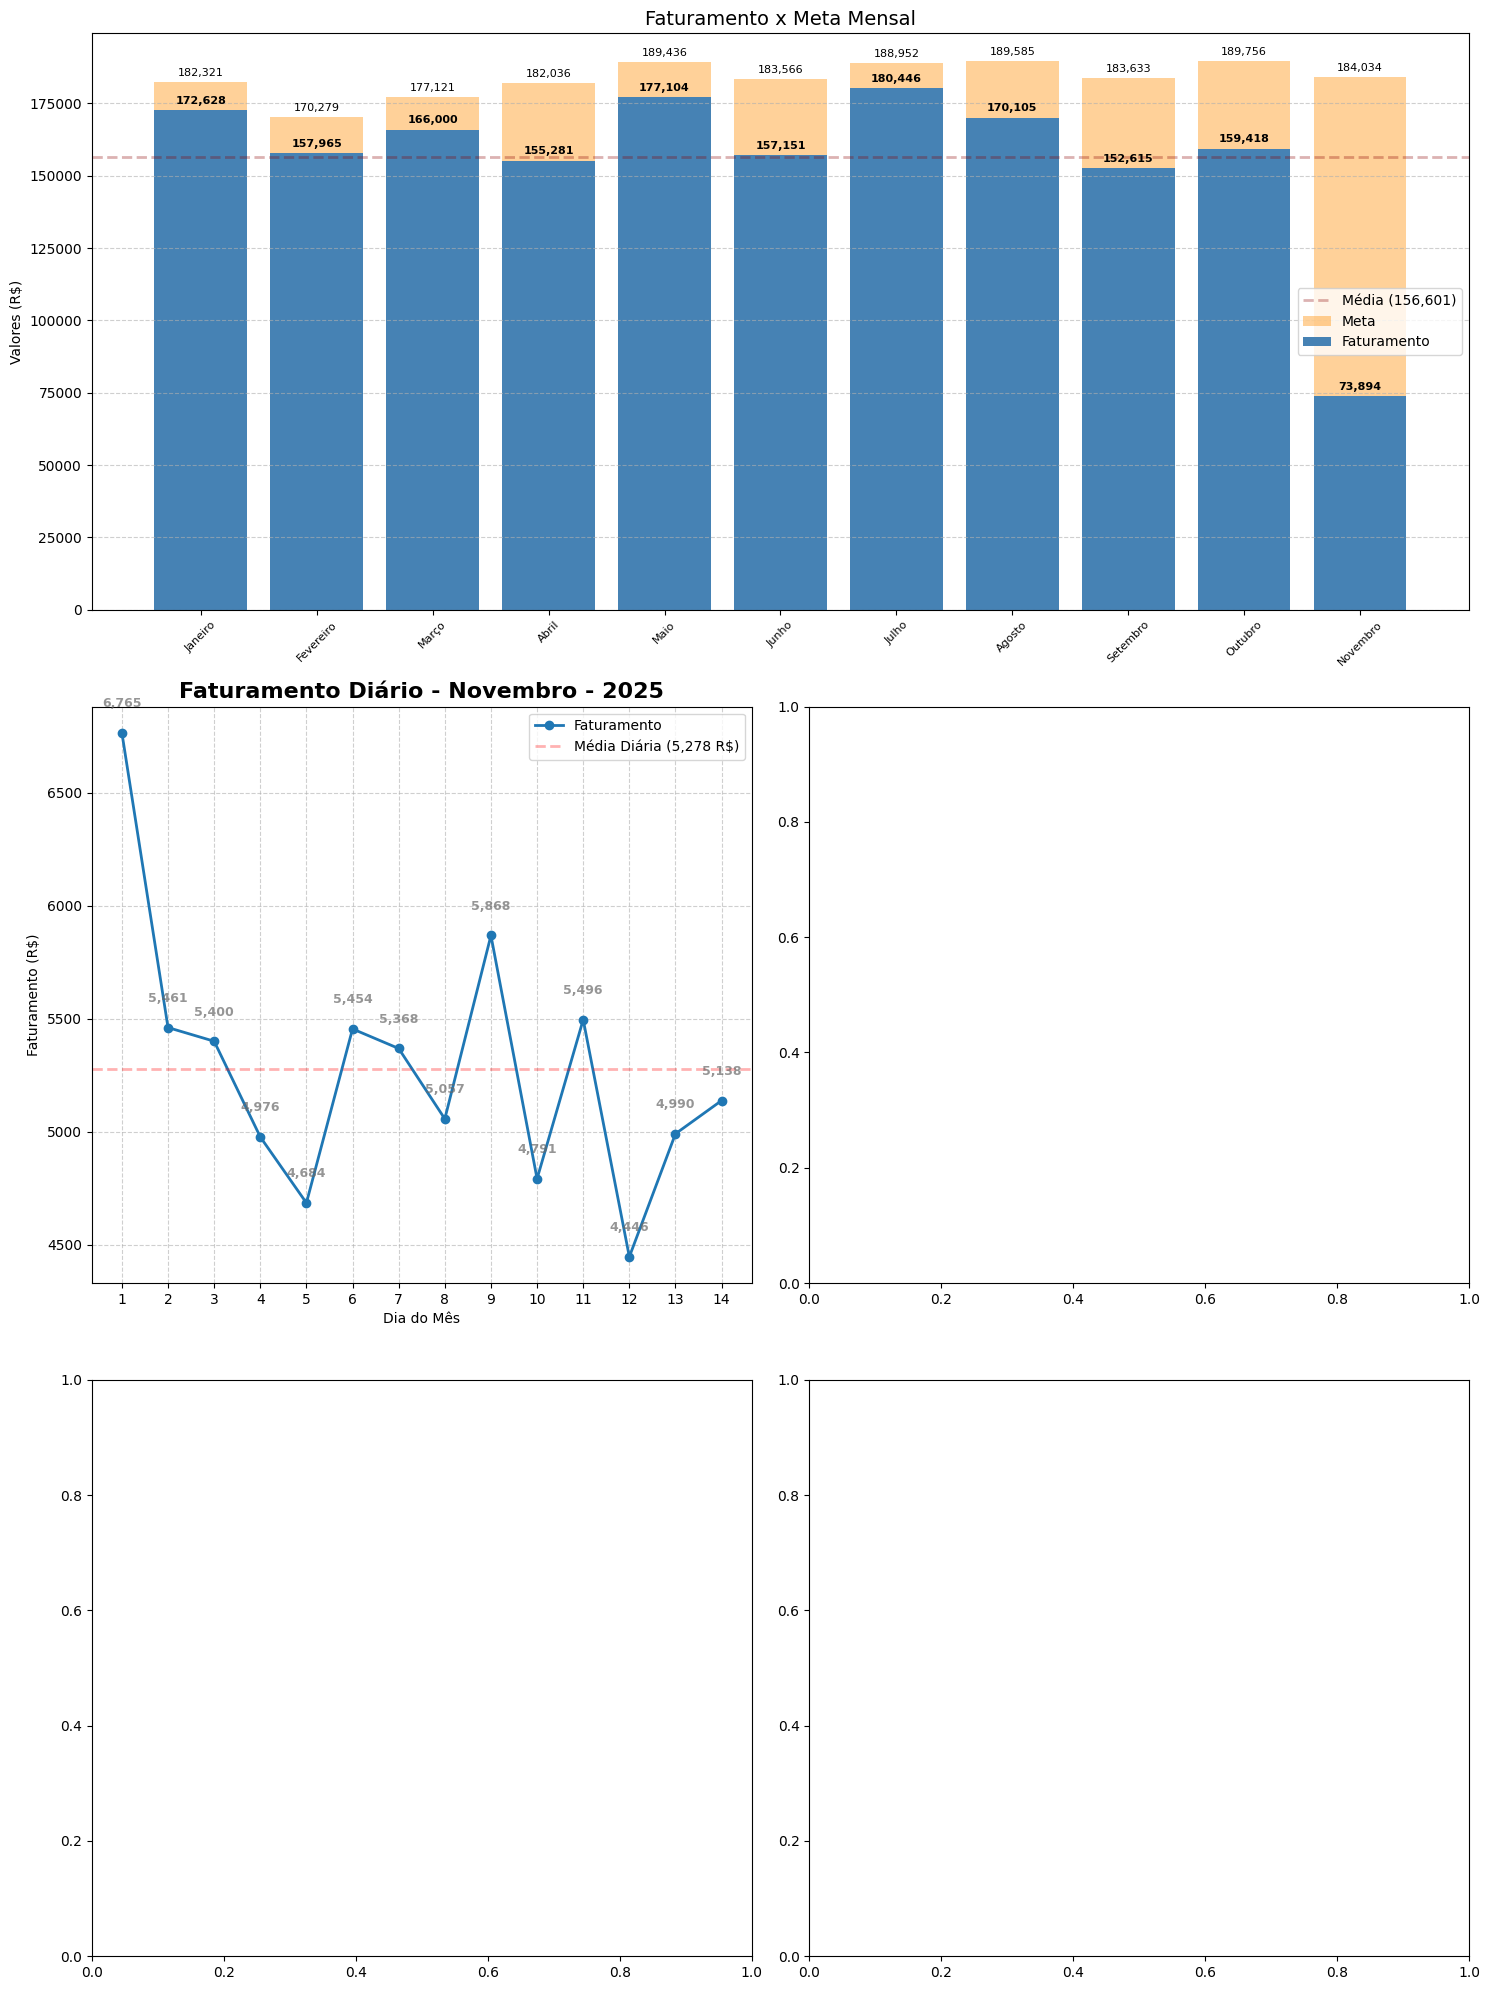

/var/folders/f3/8ygjt7g576ngdk4sjg90gxwm0000gn/T/ipykernel_1381/2451534455.py:206: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs["D"].set_xticklabels(perdas_por_mes["Mês"], rotation=45, fontsize=8)


<Figure size 640x480 with 0 Axes>

In [ ]:
# Criação de Mosaico:
mosaico = "AA;BC;DE"
fig = plt.figure(figsize=(15, 20))
axs = fig.subplot_mosaic(mosaico)

# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# GRAFICO A:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# FATURAMENTO X META MENSAL:
dados_mensal = faturamento_df.groupby("Mês")[["Faturamento", "Meta"]].sum().reset_index()
media_faturamento = dados_mensal["Faturamento"].mean()

# === Ordenar meses ===
dados_mensal["Mês"] = pd.Categorical(dados_mensal["Mês"],
                                     categories=ordem_meses,
                                     ordered=True)
dados_mensal = dados_mensal.sort_values("Mês")

# === Criar o gráfico de barras ===

barras_meta = axs["A"].bar(dados_mensal["Mês"], dados_mensal["Meta"], label="Meta", color="darkorange", alpha=0.4)
barras_faturamento = axs["A"].bar(dados_mensal["Mês"], dados_mensal["Faturamento"],label="Faturamento", color="steelblue")
axs["A"].bar_label(barras_meta, fmt="{:,.0f}", padding=3, fontsize=8, label='Meta')
axs["A"].bar_label(barras_faturamento, fmt="{:,.0f}", padding=3, fontsize=8, label='Faturamento', fontweight='bold')

# === Linha média ===
axs["A"].axhline(y=media_faturamento, color="darkred", linestyle="--", alpha=0.3, linewidth=2,
            label=f"Média ({media_faturamento:,.0f})")

# === Personalização ===
axs["A"].set_title("Faturamento x Meta Mensal", fontsize=14)
#ax.set_xlabel("Mês")
axs["A"].set_ylabel("Valores (R$)")
axs["A"].set_xticklabels(dados_mensal["Mês"], rotation=45, fontsize=8) # rotation=45, fontsize=8
#ax.set_yticklabels(fontsize=8)
axs["A"].legend()
axs["A"].grid(axis="y", linestyle="--", alpha=0.6)

#plt.savefig("faturamento_x_meta_mensal.png", dpi=300)

plt.tight_layout()


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# GRAFICO B:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# FATURAMENTO POR DIA:
# Agrupar por dia e somar o Faturamento
# Nota: Como já filtramos por mês, o 'Dia' aqui será o dia do mês (1, 2, 3...)
dados_diarios_mes = df_mes_corrente.groupby(df_mes_corrente['Dia'].dt.day)['Faturamento'].sum().reset_index()

# NOVIDADE CRUCIAL: FILTRAR APENAS DIAS COM FATURAMENTO MAIOR QUE ZERO
dados_diarios_mes = dados_diarios_mes[
    dados_diarios_mes['Faturamento'] > 0
].reset_index(drop=True) # O reset_index é opcional, mas boa prática após um filtro

# --- NOVIDADE: 1.4 Calcular a Média ---
media_diaria = dados_diarios_mes['Faturamento'].mean()

# plt.plot() é o comando para gráficos de linha
barras_meta = ax.bar(dados_mensal["Mês"], dados_mensal["Meta"], label="Meta", color="darkorange", alpha=0.4)

axs["B"].plot(
    dados_diarios_mes['Dia'],
    dados_diarios_mes['Faturamento'],
    marker='o',          # Adiciona um marcador para cada dia
    linestyle='-',       # Linha contínua
    linewidth=2,
    label="Faturamento"
)

# --- NOVIDADE: Linha de Média ---
axs["B"].axhline(
    y=media_diaria,
    color='red',
    linestyle='--', # Linha tracejada
    alpha=0.3,
    linewidth=2,
    label=f"Média Diária ({media_diaria:,.0f} R$)" # Adicionar label da média na legenda com o valor formatado
)

# --- NOVIDADE: Valores sobre os Pontos (Rótulos de Dados) ---
for dia, faturamento in zip(dados_diarios_mes['Dia'], dados_diarios_mes['Faturamento']):
    axs["B"].text(
        dia, 
        faturamento + 100,  # Adiciona um pequeno offset (+500) para ficar acima do ponto
        f"{faturamento:,.0f}", # Formata o valor sem casas decimais e com separador de milhar
        ha='center',        # Alinhamento horizontal: centralizado no ponto
        va='bottom',        # Alinhamento vertical: acima do ponto
        fontsize=9,
        alpha=0.7,
        color='dimgrey',
        weight='bold'
    )

# --- 3. Personalização e Visualização ---
axs["B"].set_title(f'Faturamento Diário - {nome_do_mes_corrente} - 2025', fontsize=16, weight='bold')
axs["B"].set_xlabel('Dia do Mês', fontsize=10)
axs["B"].set_ylabel('Faturamento (R$)', fontsize=10)

# Garantir que todos os dias de Outubro (1 a 31) apareçam no eixo X
dias = range(1, len(dados_diarios_mes) + 1)
axs["B"].set_xticks(dias)

axs["B"].legend()
axs["B"].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ajusta automaticamente o layout
plt.show()


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# GRAFICO C:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# RELAÇÃO TICKET MÉDIO X NÚMERO DE CUPONS:
# VARIÁVEIS TICKET: - - - - - - - - - - - - - - - - - - - - - - - - 
ticket_medio_mes_corrente = df_mes_corrente.groupby(df_mes_corrente['Dia'].dt.day)['Ticket Médio'].mean().reset_index()
# Filtrar faturamento maior que '0':
ticket_medio_mes_corrente = ticket_medio_mes_corrente[
    ticket_medio_mes_corrente['Ticket Médio'] > 0
].reset_index(drop=True) # O reset_index é opcional, mas boa prática após um filtro
# Linha de Média
media_ticket_mes_corrente = ticket_medio_mes_corrente['Ticket Médio'].mean()

# VARIÁVEIS CUPONS: - - - - - - - - - - - - - - - - - - - - - - - - 
dados_cupons_mes_corrente = df_mes_corrente.groupby(df_mes_corrente['Dia'].dt.day)['Cupons por Dia'].sum().reset_index()
#dados_cupons_mes_corrente.columns = ['Dia do Mês', 'Cupons por Dia']
# Filtrar cupos maior que '0':
dados_cupons_mes_corrente = dados_cupons_mes_corrente[dados_cupons_mes_corrente['Cupons por Dia'] > 0].reset_index(drop=True)
# O reset_index é opcional, mas boa prática após um filtro
# Calcular a Média de Cupons
media_cupons_mes_corrente = dados_cupons_mes_corrente['Cupons por Dia'].mean()

# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

# CONSTRUÇÃO DO GRÁFICO COM DOIS EIXOS Y:
axs["C"].grid(True, linestyle='--', alpha=0.4)

# Primeiro eixo Y - Ticket Médio:
axs["C"].plot(ticket_medio_mes_corrente['Dia'], ticket_medio_mes_corrente['Ticket Médio'],
         marker='o', linestyle='-', linewidth=2, label='Ticket Médio Diário')
axs["C"].set_ylabel('Ticket Médio (R$)', color='steelblue')
axs["C"].tick_params(axis='y', labelcolor="steelblue")
axs["C"].set_title(f'Relação Ticket Médio x Número de Cupons por Dia - {nome_do_mes_corrente} - 2025', fontsize=12, weight='bold')

# Linha de Média Ticket Médio:
media_ticket_mes_corrente = ticket_medio_mes_corrente['Ticket Médio'].mean()
axs["C"].axhline(
    y=media_ticket_mes_corrente,
    color='steelblue',
    linestyle='--', # Linha tracejada
    alpha=0.3,
    linewidth=2,
    label=f"Média Ticket Dia ({media_ticket_mes_corrente:,.0f} R$)" # Adicionar label da média na legenda com o valor formatado
)
# Valores sobre os Pontos Ticket Médio (Rótulos de Dados):
for dia, ticket in zip(ticket_medio_mes_corrente['Dia'], ticket_medio_mes_corrente['Ticket Médio']):
    axs["C"].text(
        dia,
        ticket + 0.1,  # Adiciona um pequeno offset (+5) para ficar acima do ponto
        f"{ticket:,.2f}", # Formata o valor sem casas decimais e com separador de milhar
        ha='center',
        va='bottom',
        fontsize=9,
        color='dimgrey',
        weight='bold'
    )

# - - - - - - - - - - - - - - - - - - - - - - - - - - -
ax2 = axs["C"].twinx()  # Criar um segundo eixo Y compartilhando o eixo X
# - - - - - - - - - - - - - - - - - - - - - - - - - - -

# Segundo eixo Y - Cupons por Dia:
ax2.plot(dados_cupons_mes_corrente['Dia'], dados_cupons_mes_corrente['Cupons por Dia'],
         marker='s', linestyle='-', color='darkred', linewidth=2, alpha=0.15, label=f'Cupons por Dia ({media_cupons_dia:.0f})')
ax2.set_ylabel('Cupons por Dia', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')


# Adicionar legendas ancorando a posição fixa (x, y) / bbox_transform para posicionar em relação a área do gráfico
axs["C"].legend(bbox_to_anchor=(0.65, 1), bbox_transform=axs["C"].transAxes)
ax2.legend()


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# GRAFICO D:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# PERDAS POR MÊS:
perdas_mes = axs["D"].bar(perdas_por_mes['Mês'], perdas_por_mes['Quantidade'], color='red', alpha=0.3, label='Perdas')
media_perdas_mes = perdas_por_mes['Quantidade'].mean()

# --- NOVIDADE: Linha de Média ---
axs["D"].axhline(
    y=media_perdas_mes,
    #color='salmon',
    linestyle='--', # Linha tracejada
    alpha=0.5,
    linewidth=2,
    label=f"Média Mês ({media_perdas_mes:,.0f})" # Adicionar label da média na legenda com o valor formatado
)

# === Personalização ===
axs["D"].set_title('Perdas Por Mês', fontsize=13)
axs["D"].set_xlabel("Mês")
axs["D"].set_ylabel("Quantidade")
axs["D"].set_xticklabels(perdas_por_mes["Mês"], rotation=45, fontsize=8)
axs["D"].grid(axis="y", linestyle="--", alpha=0.5)
axs["D"].legend()

# === Valores sobre as barras ===
axs["D"].bar_label(
    perdas_mes, # Variável que recebeu a instrução do gráfico
    label=perdas_por_mes["Quantidade"], # Informação a ser exibida em cima de cada barra
    padding=3, # Posição do texto em relação à barra
    fontsize=9, # Tamanho da fonte
    fontweight='bold', # Fonte em negrito
    color="dimgrey" # Cor do texto
    )

# Muda a cor da barra para valores abaixo da média:
for i, barra in enumerate(perdas_mes):
    if perdas_por_mes["Quantidade"].iloc[i] < media_perdas_mes:
        barra.set_color('green')

# Destacar área no gráfico (exemplo: período de redução de perdas)
#plt.axvspan(4.5, 9.5, color='lightgreen', alpha=0.3) 
#plt.text(5.5, 70, 'Período de Redução de Perdas', fontsize=10, color='darkgreen')

plt.tight_layout() # Ajusta o layout automaticamente


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# GRAFICO E:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# PERDAS POR MOTIVO:
perdas_cat = axs["E"].pie(
    perdas_motivo['Item'],
    labels=perdas_motivo['Motivo'],
    autopct='%1.1f%%',
    startangle=140
)

# === Personalização ===
axs["E"].set_title(f'Perdas por Categoria ({nome_do_mes_corrente})', fontsize=13)

plt.tight_layout() # Ajusta o layout automaticamente


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# # AJUSTES FIGURA:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
fig.suptitle("Dashboard - BPS")
# Gerar arquivo .PNG do gráfico:
#plt.savefig("dashboard_BPS.png", dpi=300, bbox_inches="tight")

plt.show()